In [1]:
import pandas as pd

In [2]:
import pandas as pd
df = pd.read_csv("data/Telco_Customer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [11]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [12]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [15]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [18]:
df["TotalCharges"].dtype

dtype('float64')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
for col in df.select_dtypes(include="str").columns:
    print("\n", col)
    print(df[col].unique())


 customerID
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

 gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

 Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

 PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

 DeviceProtect

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [22]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

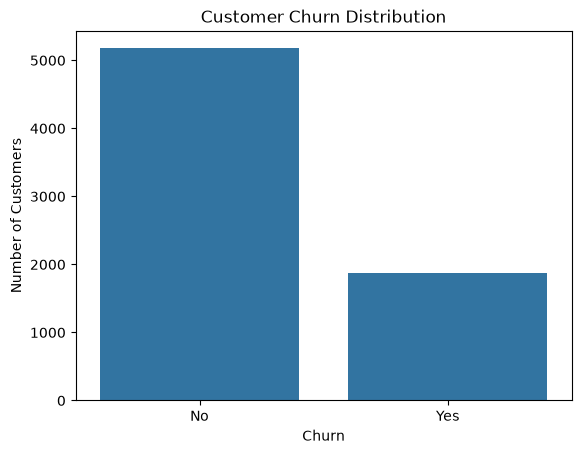

In [24]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

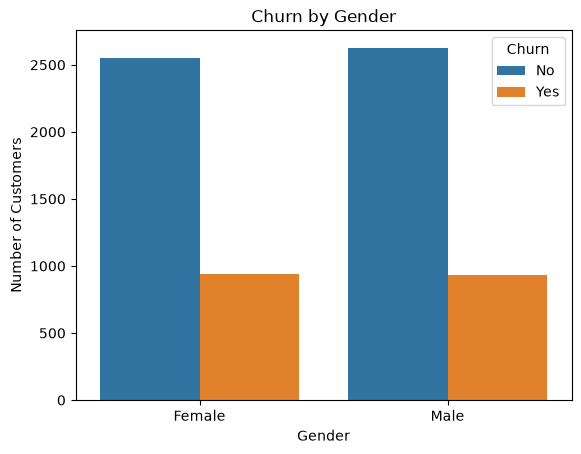

In [25]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

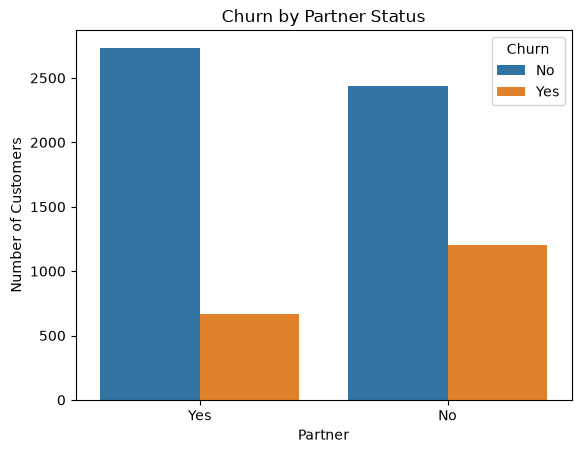

In [26]:
sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

In [27]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
# Check data types of all columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [29]:
# Check the shape of the dataset
df.shape

(7043, 21)

In [30]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [31]:
print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [32]:
(7043, 20)
(7043,)

(7043,)

In [33]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
y.value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [35]:
X.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [36]:
X = X.drop('customerID', axis=1)

In [37]:
X.shape

(7043, 19)

In [38]:
X.shape

(7043, 19)

In [39]:
X.select_dtypes(include='str').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [40]:
X = pd.get_dummies(X, drop_first=True)

In [41]:
X.shape

(7043, 30)

In [42]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
X_train.shape


(5634, 30)

In [46]:
X_test.shape

(1409, 30)

In [47]:
X = df.drop('Churn', axis=1)

In [48]:
y = df['Churn']

In [49]:
X = X.drop('customerID', axis=1)

In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
X.shape

(7043, 30)

In [52]:
X.columns[:5]

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male'],
      dtype='str')

In [53]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [54]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [55]:
df.dtypes['TotalCharges']

dtype('float64')

In [56]:
df.dtypes['TotalCharges']

dtype('float64')

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
import pandas as pd

In [59]:
import numpy as np

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [63]:
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

In [64]:
X = pd.get_dummies(X, drop_first=True)

In [65]:
X = X.fillna(0)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [67]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

In [68]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [69]:
y_pred = model.predict(X_test)

In [70]:
X_train.shape

(5634, 30)

In [71]:
X_test.shape

(1409, 30)

In [72]:
X_train.shape

(5634, 30)

In [73]:
accuracy_score(y_test, y_pred)

0.8069552874378992

In [74]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n          No       0.85      0.89      0.87      1035\n         Yes       0.66      0.57      0.61       374\n\n    accuracy                           0.81      1409\n   macro avg       0.75      0.73      0.74      1409\nweighted avg       0.80      0.81      0.80      1409\n'

In [75]:
confusion_matrix(y_test, y_pred)

array([[925, 110],
       [162, 212]])

In [76]:
(924 + 208) / (924 + 111 + 166 + 208)

0.8034066713981547

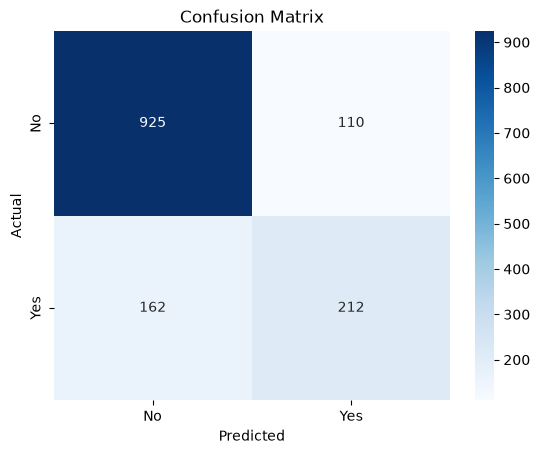

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.841778397788628

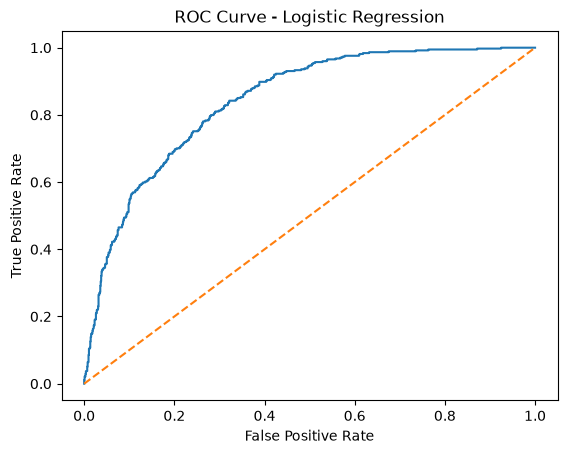

In [79]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.show()

In [80]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.841778397788628


In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7927608232789212
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [82]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.8264408793820558


In [83]:
from sklearn.linear_model import LogisticRegression

model_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [84]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [85]:
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]

auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print("Balanced Logistic Regression ROC-AUC:", auc_balanced)

Balanced Logistic Regression ROC-AUC: 0.8414012245214291


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [87]:
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = [
        "Yes" if p >= threshold else "No"
        for p in y_prob
    ]

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred_threshold, pos_label="Yes"))
    print("Recall:", recall_score(y_test, y_pred_threshold, pos_label="Yes"))
    print("F1:", f1_score(y_test, y_pred_threshold, pos_label="Yes"))


Threshold: 0.3
Precision: 0.5193370165745856
Recall: 0.7540106951871658
F1: 0.6150490730643402

Threshold: 0.4
Precision: 0.5668934240362812
Recall: 0.6684491978609626
F1: 0.6134969325153374

Threshold: 0.5
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1: 0.6091954022988506

Threshold: 0.6
Precision: 0.7095238095238096
Recall: 0.3983957219251337
F1: 0.5102739726027398

Threshold: 0.7
Precision: 0.7303370786516854
Recall: 0.17379679144385027
F1: 0.28077753779697623


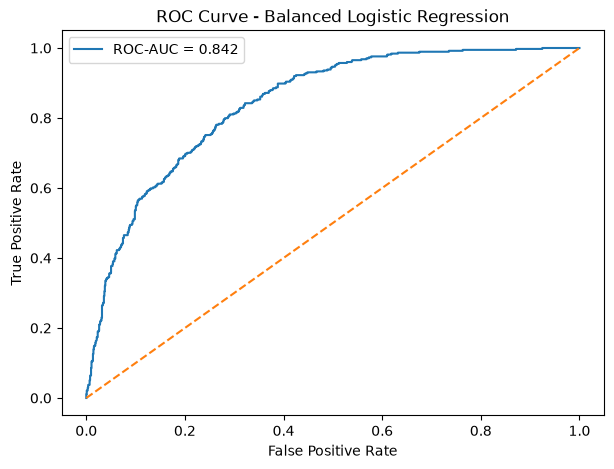

In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend()
plt.show()

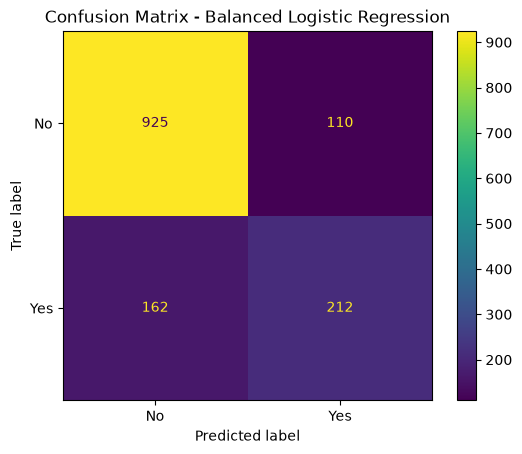

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=["No", "Yes"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [90]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.82      0.84      1035
         Yes       0.56      0.62      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



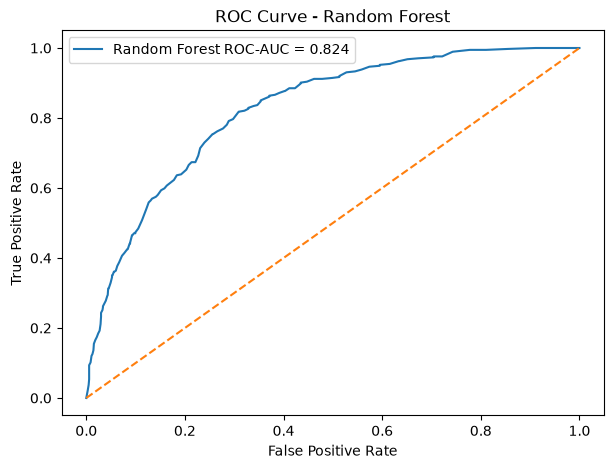

Random Forest ROC-AUC: 0.8243470510733938


In [92]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf,
    pos_label="Yes"
)

auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC-AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("Random Forest ROC-AUC:", auc_rf)

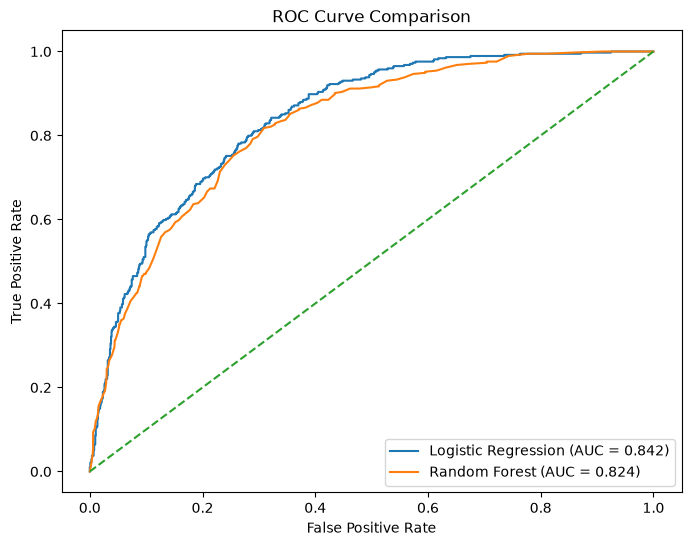

In [93]:
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
plt.plot(
    fpr, tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

# Random Forest ROC
plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

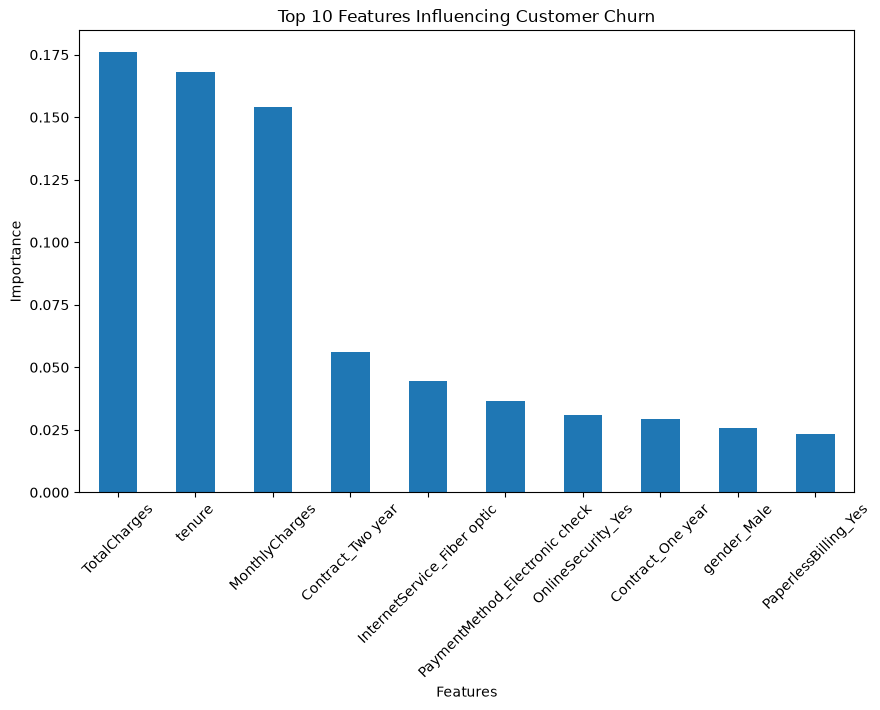

In [94]:
# Random Forest Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [95]:
# Model Comparison

accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred, pos_label="Yes")
recall_lr = recall_score(y_test, y_pred, pos_label="Yes")
f1_lr = f1_score(y_test, y_pred, pos_label="Yes")

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label="Yes")
recall_rf = recall_score(y_test, y_pred_rf, pos_label="Yes")
f1_rf = f1_score(y_test, y_pred_rf, pos_label="Yes")

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1 Score": [f1_lr, f1_rf],
    "ROC-AUC": [auc, auc_rf]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,Random Forest,0.769340,0.558753,0.622995,0.589128,0.824347


In [96]:
# Select a sample customer from the test set

sample_customer = X_test.iloc[[0]]
prediction = model.predict(sample_customer)
print("Predicted Churn:", prediction[0])

Predicted Churn: No


In [97]:
# Calculate churn probability for the sample customer

probability = model.predict_proba(sample_customer)[0][1]
print("Predicted Churn:", prediction[0])
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: No
Churn Probability: 4.5 %
